## 📦 Kütüphaneleri İçe Aktar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, auc,
    precision_recall_curve, average_precision_score
)

import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 📂 Model ve Veriyi Yükle

In [2]:
# NOT: Notebook 3 ve 4'ü "Add Data" ile ekleyin!

# Notebook 3'ten test verisi
data_dir_nb3 = '/kaggle/input/3-feature-engineering-notebook/'
X_test = np.load(data_dir_nb3 + 'X_test_fe.npy')
y_test = np.load(data_dir_nb3 + 'y_test.npy')

# Load feature names
with open(data_dir_nb3 + 'feature_names.txt', 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]

# Notebook 4'ten model ve sonuçlar
data_dir_nb4 = '/kaggle/input/4-model-optimization-notebook/'
with open(data_dir_nb4 + 'best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

with open(data_dir_nb4 + 'best_params.json', 'r') as f:
    best_info = json.load(f)

# Output directory for saving plots
output_dir = '/kaggle/working/'

print("✅ Data and model loaded successfully!")
print(f"\nX_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nBest Model: {best_info['best_model']}")
print(f"Test ROC-AUC: {best_info['test_roc_auc']:.4f}")

✅ Data and model loaded successfully!

X_test shape: (2000, 19)
y_test shape: (2000,)
Number of features: 19

Best Model: CatBoost
Test ROC-AUC: 0.8741


## 📊 Tahminleri Yap

In [3]:
# Predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Predictions generated!")
print(f"\nPredicted churn distribution:")
print(pd.Series(y_pred).value_counts())
print(f"\nActual churn distribution:")
print(pd.Series(y_test).value_counts())

Predictions generated!

Predicted churn distribution:
0    1757
1     243
Name: count, dtype: int64

Actual churn distribution:
0    1593
1     407
Name: count, dtype: int64


## 📈 Model Performansını Değerlendir

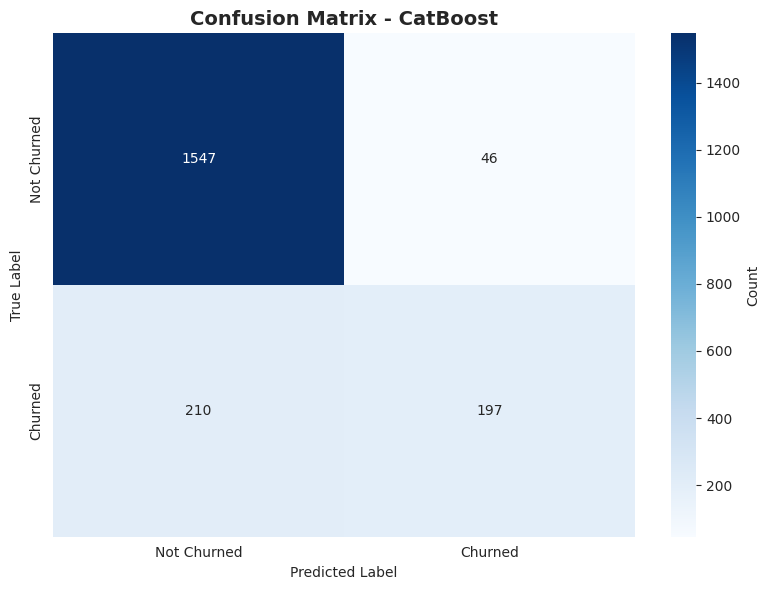


Confusion Matrix Breakdown:
  True Negatives (TN): 1547
  False Positives (FP): 46
  False Negatives (FN): 210
  True Positives (TP): 197

  Sensitivity (Recall): 0.4840
  Specificity: 0.9711


In [4]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_info["best_model"]}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(output_dir + 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Display metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP): {tp}")
print(f"\n  Sensitivity (Recall): {tp/(tp+fn):.4f}")
print(f"  Specificity: {tn/(tn+fp):.4f}")

## 🔍 Confusion Matrix

In [5]:
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))
print("="*60)


📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Churned       0.88      0.97      0.92      1593
     Churned       0.81      0.48      0.61       407

    accuracy                           0.87      2000
   macro avg       0.85      0.73      0.76      2000
weighted avg       0.87      0.87      0.86      2000



## 📈 ROC Curve

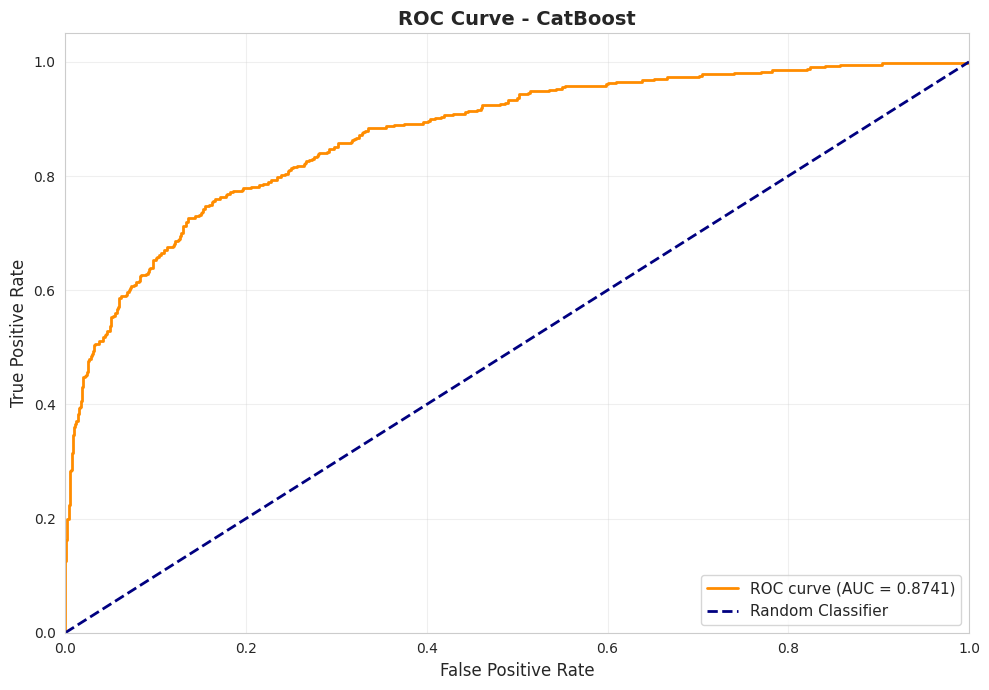

ROC-AUC Score: 0.8741


In [6]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_info["best_model"]}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir + 'roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 📊 Precision-Recall Curve

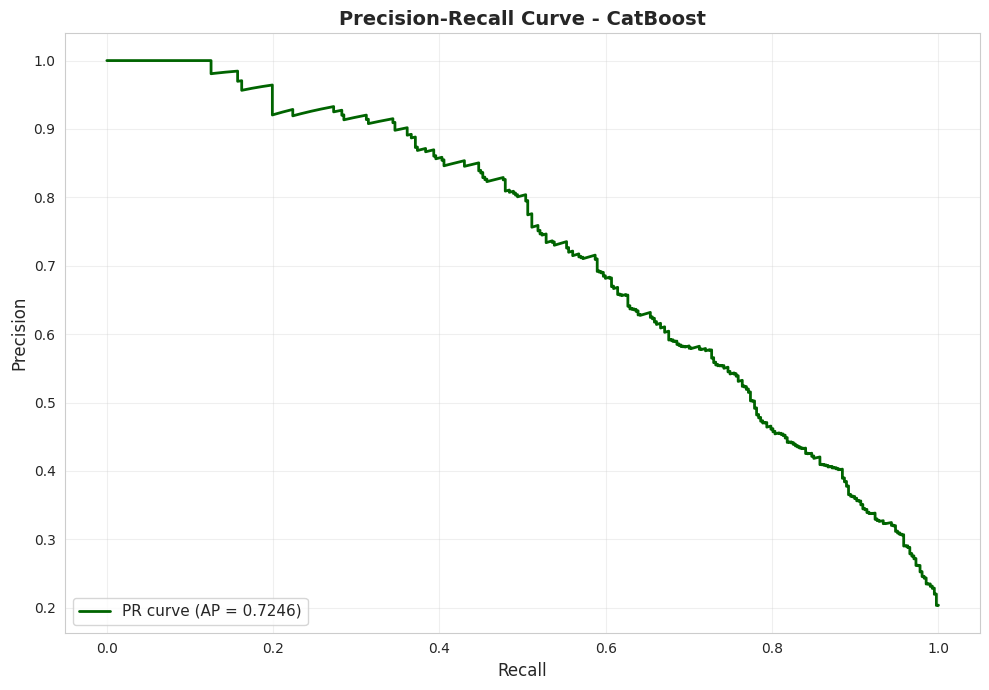

Average Precision Score: 0.7246


In [7]:
# Calculate PR curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='darkgreen', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Precision-Recall Curve - {best_info["best_model"]}', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir + 'pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")

## 🎯 Özellik Önem Analizi

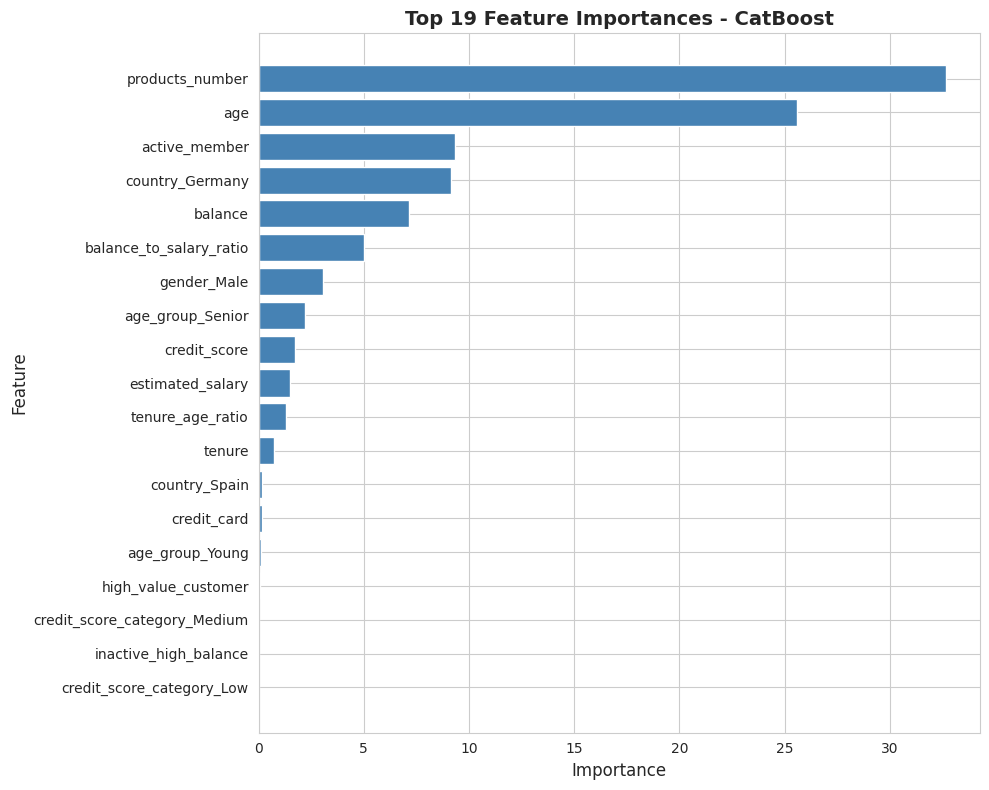


Top 19 Most Important Features:
                     Feature  Importance
             products_number   32.655017
                         age   25.575966
               active_member    9.335746
             country_Germany    9.155130
                     balance    7.152960
     balance_to_salary_ratio    4.998196
                 gender_Male    3.067925
            age_group_Senior    2.196868
                credit_score    1.715011
            estimated_salary    1.506251
            tenure_age_ratio    1.301846
                      tenure    0.734881
               country_Spain    0.186884
                 credit_card    0.162396
             age_group_Young    0.118542
         high_value_customer    0.059942
credit_score_category_Medium    0.040295
       inactive_high_balance    0.036145
   credit_score_category_Low    0.000000


In [8]:
# Get feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    # Top 20 features
    top_n = min(20, len(importance_df))
    top_features = importance_df.head(top_n)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Top {top_n} Feature Importances - {best_info["best_model"]}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(output_dir + 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nTop {top_n} Most Important Features:")
    print(top_features.to_string(index=False))
else:
    print("Model does not have feature_importances_ attribute.")

## 🧠 SHAP Değerleri - Model Yorumlanabilirliği

In [9]:
print("Calculating SHAP values... (this may take a few minutes)\n")

# Create SHAP explainer
# For tree-based models, use TreeExplainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set (sample if too large)
sample_size = min(500, len(X_test))
X_test_sample = X_test[:sample_size]
shap_values = explainer.shap_values(X_test_sample)

print("✅ SHAP values calculated!")

Calculating SHAP values... (this may take a few minutes)

✅ SHAP values calculated!


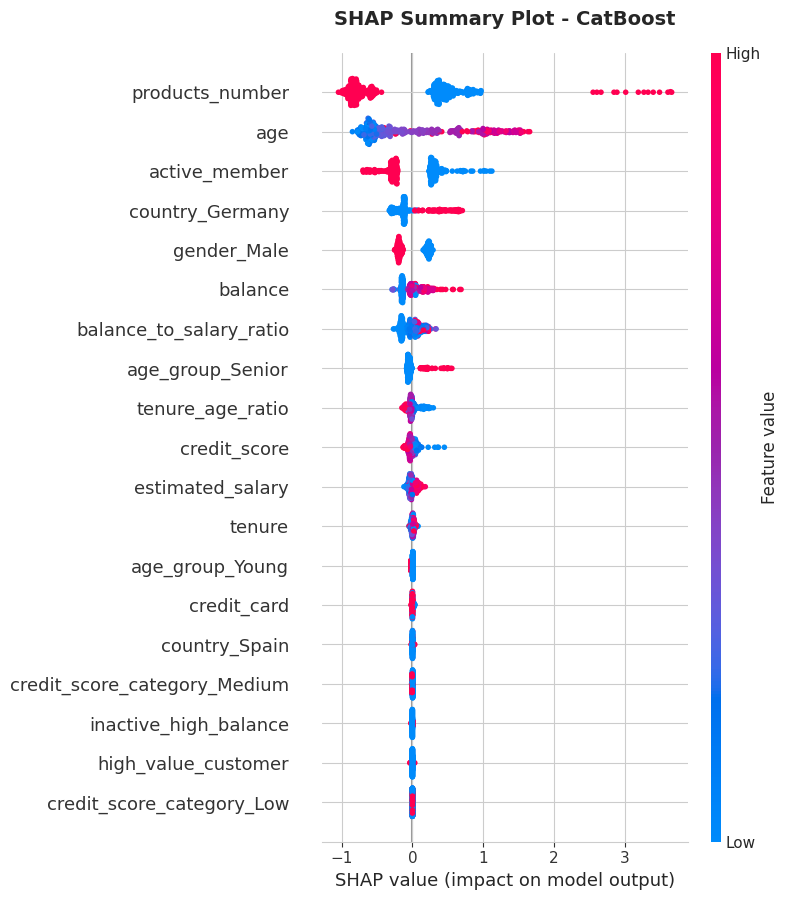

SHAP summary plot saved!


In [10]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title(f'SHAP Summary Plot - {best_info["best_model"]}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(output_dir + 'shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("SHAP summary plot saved!")

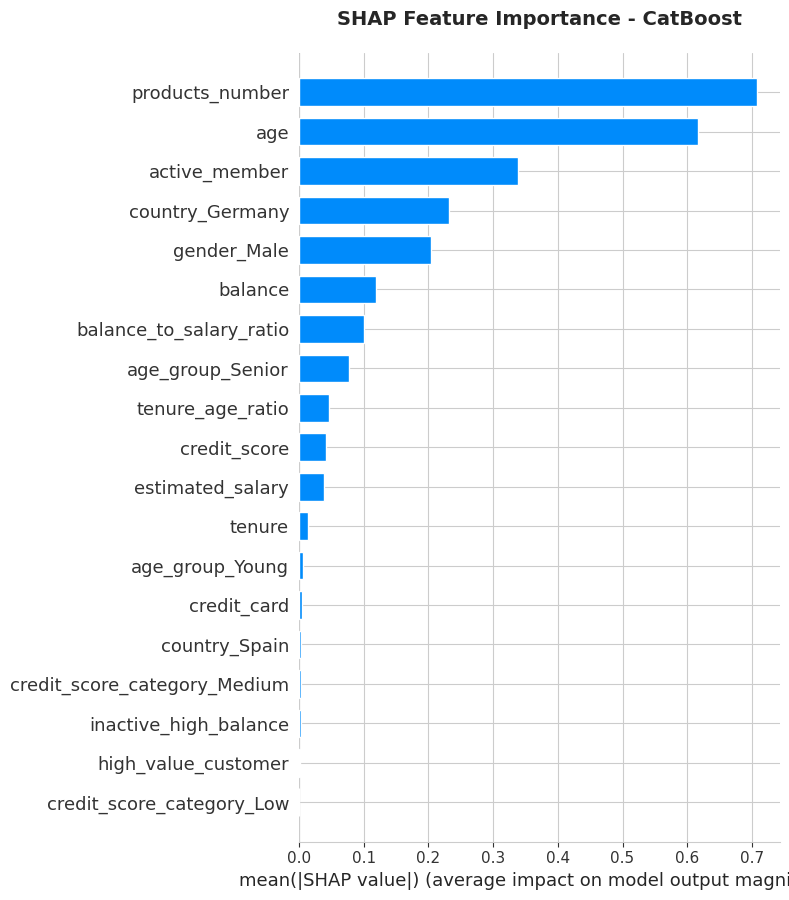

SHAP bar plot saved!


In [11]:
# SHAP Bar Plot (mean absolute SHAP values)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance - {best_info["best_model"]}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(output_dir + 'shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("SHAP bar plot saved!")

## 📊 SHAP Görselleştirmeleri

In [12]:
# Create evaluation report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

report_content = f"""# Model Evaluation Report - Bank Customer Churn

## Model Information

- **Best Model:** {best_info['best_model']}
- **Test Set Size:** {len(y_test)} samples

## Performance Metrics

### Classification Metrics

| Metric | Score |
|--------|-------|
| Accuracy | {accuracy_score(y_test, y_pred):.4f} |
| Precision | {precision_score(y_test, y_pred):.4f} |
| Recall | {recall_score(y_test, y_pred):.4f} |
| F1-Score | {f1_score(y_test, y_pred):.4f} |
| ROC-AUC | {roc_auc:.4f} |
| Average Precision | {avg_precision:.4f} |

### Confusion Matrix

| | Predicted Not Churned | Predicted Churned |
|---|---|---|
| **Actual Not Churned** | {tn} | {fp} |
| **Actual Churned** | {fn} | {tp} |

- **True Negatives (TN):** {tn}
- **False Positives (FP):** {fp}
- **False Negatives (FN):** {fn}
- **True Positives (TP):** {tp}

### Additional Metrics

- **Sensitivity (Recall):** {tp/(tp+fn):.4f}
- **Specificity:** {tn/(tn+fp):.4f}

## Model Insights

### SHAP Analysis

SHAP (SHapley Additive exPlanations) values provide interpretability for the model's predictions.
See `shap_summary.png` and `shap_bar.png` for visualizations.

### Feature Importance

See `feature_importance.png` for the top contributing features.

## Visualizations

The following plots are saved:

1. `confusion_matrix.png` - Confusion matrix heatmap
2. `roc_curve.png` - ROC curve
3. `pr_curve.png` - Precision-Recall curve
4. `feature_importance.png` - Feature importance plot
5. `shap_summary.png` - SHAP summary plot
6. `shap_bar.png` - SHAP feature importance bar plot

## Conclusion

The {best_info['best_model']} model achieved a test ROC-AUC score of {roc_auc:.4f}, 
demonstrating strong performance in predicting bank customer churn.

---

*Report generated automatically from Model Evaluation Notebook*
"""

# Save report
with open(output_dir + 'evaluation_report.md', 'w') as f:
    f.write(report_content)

print("✅ Evaluation report saved!")
print(f"\nFile: evaluation_report.md")

✅ Evaluation report saved!

File: evaluation_report.md


## 📝 Model Değerlendirme Özeti

### Model Performansı:
- **Accuracy:** [0.87]
- **Precision:** [0.85(macro avg)]
- **Recall:** [0.73(macro avg)]
- **F1-Score:** [0.76(macro avg)]
- **ROC-AUC:** [0.8741]

### Confusion Matrix Analizi:
- **True Positives (TP):** [197] - Doğru kayıp tahminleri
- **True Negatives (TN):** [1547] - Doğru kalmaya devam tahminleri
- **False Positives (FP):** [46] - Yanlış kayıp uyarıları
- **False Negatives (FN):** [210] - Kaçırılan kayıp müşterileri

### Sonraki Adımlar:
1. ✅ Final pipeline oluştur (preprocessing + model)
2. 🚀 Streamlit ile deployment için hazırla
3. 📊 Gerçek zamanlı izleme sistemi kur